In [2]:
import sys
from pathlib import Path

project_root = Path.cwd().parents[1]  # importing functions from other folders
sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from _data.data_utils import read_in
from _fitting.fitting_utils import hist_plot, CI_plot, CI_plot_alt, CI_plot_both, plot_posteriors_side_by_side, plot_spline_Bknots
import pymc as pm
import pymc.math as pmm
import arviz as az
from patsy import dmatrix
import nutpie
import time
from IPython.display import display
from pymc.variational.callbacks import CheckParametersConvergence
import io
import base64
import seaborn as sns
import pyreadr
from matplotlib import colors as mcolors

az.style.use("arviz-darkgrid")


if '___laptop' in os.listdir('../../'):
    # laptop folder
    folder = "../../../_data/p-dengue/"
elif '___server' in os.listdir('../../'):
    # server folder
    folder = "../../../../../../data/lucaratzinger_data/p_dengue/"

In [3]:
data = read_in(folder, admin=2, max_lag=6, dropna=False, end_year=2024, end_month=12)

admin2_year_month_cases  = pyreadr.read_r(os.path.join(folder, 'cases_deaths_pop_2016_2024_38.rds'))[None]
admin2_year_month_cases = admin2_year_month_cases.loc[admin2_year_month_cases['admin2'].isin(data['admin2'].unique())]
admin2_year_month_cases = admin2_year_month_cases[['region', 'admin1', 'admin2']].drop_duplicates().reset_index(drop=True)

In [3]:
admin2_list = sorted(data['admin2'].unique())
admin1_list = sorted(data['admin1'].unique())
region_list = sorted(admin2_year_month_cases['region'].unique())

admin2_to_admin1 = {}
for _, row in data.iterrows():
    a2 = row['admin2']
    a1 = row['admin1']
    admin2_to_admin1[a2] = a1
admin2_to_admin1 = dict(sorted(admin2_to_admin1.items()))

admin1_to_region = {}
for _, row in admin2_year_month_cases.iterrows():
    a1 = row['admin1']
    r = row['region']
    admin1_to_region[a1] = r
admin1_to_region = dict(sorted(admin1_to_region.items()))

admin1_a2_clusters = {}
for a1 in admin1_list:
    admin1_a2_clusters[a1] = sorted(data.loc[data['admin1'] == a1, 'admin2'].unique())

region_a2_clusters = {}
for a1, a2_list in admin1_a2_clusters.items():
    region = admin1_to_region.get(a1, "Unknown")
    if region not in region_a2_clusters:
        region_a2_clusters[region] = []
    region_a2_clusters[region].extend(a2_list)
region_clusters = dict(sorted(region_a2_clusters.items()))

# admin1 clustering
admin2_clustered_by_admin1 = []
admin1_partitions = []
for admin1, a2_list in admin1_a2_clusters.items():
    admin1_partitions.append(len(a2_list))
    admin2_clustered_by_admin1.extend(a2_list)

# region clustering
admin2_clustered_by_region = []
region_partitions = []
for region, a2_list in region_clusters.items():
    region_partitions.append(len(a2_list))
    admin2_clustered_by_region.extend(a2_list)

In [4]:
def find_weather_columns(data, max_lag=None,log=False, pop_weighted=True, var_names=None):
    # Weather columns
    weather_columns = [c for c in data.columns if c.endswith(')')]
    if max_lag is not None:
        weather_columns = [c for c in weather_columns if int(c[-2]) <= max_lag]
    
    # tp columns
    if log:
        weather_columns = [c for c in weather_columns if not ((c.startswith('tp') and '_log' not in c))]
    else:
        weather_columns = [c for c in weather_columns if not ((c.startswith('tp') and '_log' in c))]
    weather_columns = [c for c in weather_columns if not (c.startswith('tp') and 'log1p' in c)]
    
    # pop_weighted
    if pop_weighted:
        weather_columns = [c for c in weather_columns if 'pop_weighted' in c]
    else:
        weather_columns = [c for c in weather_columns if 'pop_weighted' not in c]
    
    if var_names is not None:
        weather_columns = [c for c in weather_columns if any(v in c for v in var_names)]

    # sort columns by name
    weather_columns = sorted(weather_columns)
    
    return weather_columns

---

In [5]:
max_lag = 6
log_tp = False
var_names = ['rh_mean', 't2m_mean', 't2m_max', 't2m_min', 'tp_24hmean', 'tp_24hmax']
w_data = read_in(folder, admin=2, max_lag=max_lag, dropna=False, end_year=2024, end_month=12)
w_weather_columns = find_weather_columns(w_data, max_lag=max_lag, log=log_tp, pop_weighted=True, var_names=var_names)
w_data = w_data[w_weather_columns + ['admin1', 'admin2', 'year', 'month']]
w_cov_columns = w_weather_columns
for c in w_cov_columns:
    w_data[c] = (w_data[c] - w_data[c].mean()) / w_data[c].std()

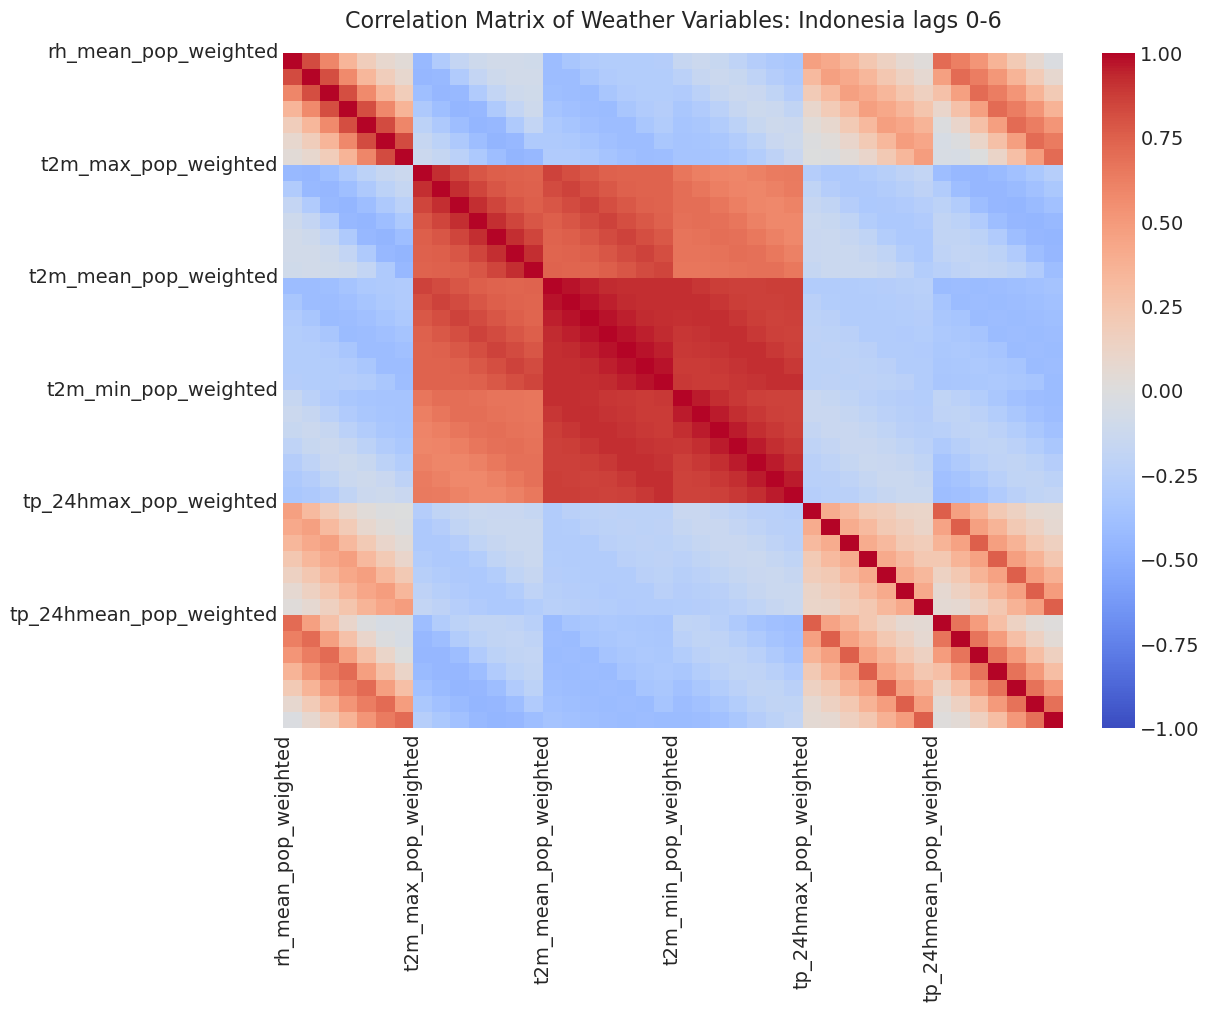

In [6]:
# use seaborn to plot the correlation matrix
plt.figure(figsize=(12, 10))
colormap = ['coolwarm', 'seismic'][0]
sns.heatmap(w_data[w_cov_columns].corr(), annot=False, cmap=colormap, vmin=-1, vmax=1)
plt.title('Correlation Matrix of Weather Variables: Indonesia lags 0-6', y=1.025)
# instead of using all column names, use only every sixth column name, and remove the lag number
xticks = [i for i in range(len(w_cov_columns)) if i % 7 == 0]
xtick_labels = [w_cov_columns[i].split('(')[0] for i in xticks]
plt.xticks(xticks, xtick_labels, rotation=90)
yticks = [i for i in range(len(w_cov_columns)) if i % 7 == 0]
ytick_labels = [w_cov_columns[i].split('(')[0] for i in yticks]
plt.yticks(yticks, ytick_labels, rotation=0)
# can you shift the ticks a bit to the right and downwards so they are not on the grid lines?
plt.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=True, labeltop=False, labelrotation=90)
plt.tick_params(axis='y', which='both', left=False, right=False, labelleft=True, labelright=False)
plt.show()

- relative humidity (rh): shows positive autocorrelation with lag up to 3/4, then zero
- total precipitation (tp): max shows weaker autocorrelation, mean shows greater autocorrelation positive up to lag3, then zero or slightly negative for tp_mean. Correlation between max and mean is marked but not super strong
- temperature (t2m): strong autocorrelation up to lag 6, mean and min show highest autocorrelation, max a bit less. mean and min are very correlated, max less so.

rh-t2m: negative.
- rh-t2m_max: sharp. negative strongest on diagonal and above (rh of previous month), then goes to zero
- rh-t2m_mean: more diffuse, strong
- rh-t2m_min: less strong on diagonal and below (rh of next month), stronger outside

rh-tp: positive.
- rh-tp_max: less strong. strong on diagonal and above (rh of previous month), goes to zero
- rh-tp_mean: strong on diagonal and above (rh of previous month), goes to slightly negative

t2m-tp: negative. stronger on tp_mean (possibly because tp_max has higher variability)
- t2m_max-tp_mean: strong on diagonal and two above diagonal (mean precipitation 1 and 2 months prior is strongly negatively correlated with mean temperature). Correlation with future rainfall is weaker.
- t2m_mean-tp_mean: less trong and more diffuse than t2m_max so that negative correlation is not as strong on the diagonal or above, but remains stronger, especially with future rainfall
- t2m_min-tp_mean: nearly uncorrelated on diagonal, negative at the edges (min temperature and tp have strong negative correlation at 5-6 month lag)

---

How much is explained by ciclicity? (subtract month average)

In [7]:
max_lag = 6
log_tp = False
var_names = ['rh_mean', 't2m_mean', 't2m_max', 't2m_min', 'tp_24hmean', 'tp_24hmax']
anom_data = read_in(folder, admin=2, max_lag=max_lag, dropna=False, end_year=2024, end_month=12)
w_weather_columns = find_weather_columns(anom_data, max_lag=max_lag, log=log_tp, pop_weighted=True, var_names=var_names)
anom_data = anom_data[w_weather_columns + ['admin1', 'admin2', 'year', 'month']]
w_cov_columns = w_weather_columns
anom_cov_columns = [f'{c}_anom' for c in w_cov_columns]

# monthly climatology per admin2
clim = anom_data.groupby(['admin2', 'month'])[w_weather_columns].mean().reset_index()
clim = clim.rename(columns={c: f"{c}_clim" for c in w_weather_columns})

# merge climatology back and compute anomalies
anom_data = anom_data.merge(clim, on=['admin2', 'month'], how='left')
for c in w_cov_columns:
    anom_data[f'{c}_anom'] = anom_data[c] - anom_data[f'{c}_clim']

for l in anom_cov_columns:
    anom_data[l] = (anom_data[l] - anom_data[l].mean()) / anom_data[l].std()

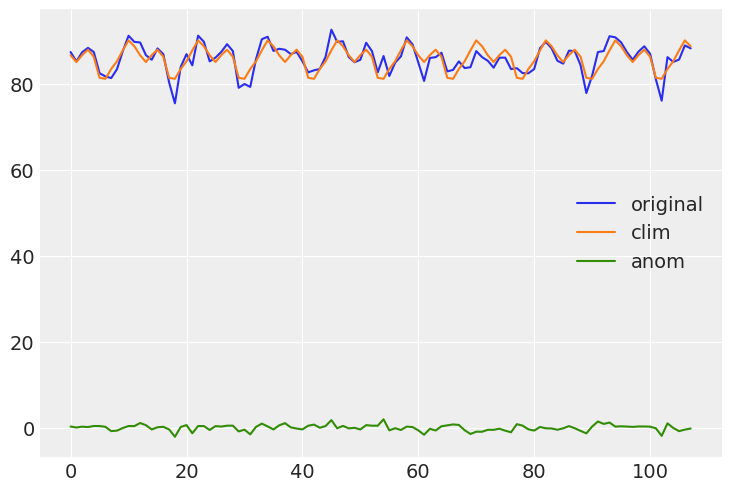

In [8]:
plt.plot(data.loc[data['admin2'] == 'ACEH BARAT']['rh_mean_pop_weighted(0)'], label='original')
plt.plot(anom_data.loc[anom_data['admin2'] == 'ACEH BARAT']['rh_mean_pop_weighted(0)_clim'], label='clim')
plt.plot(anom_data.loc[anom_data['admin2'] == 'ACEH BARAT']['rh_mean_pop_weighted(0)_anom'], label='anom')
plt.legend()
plt.show()

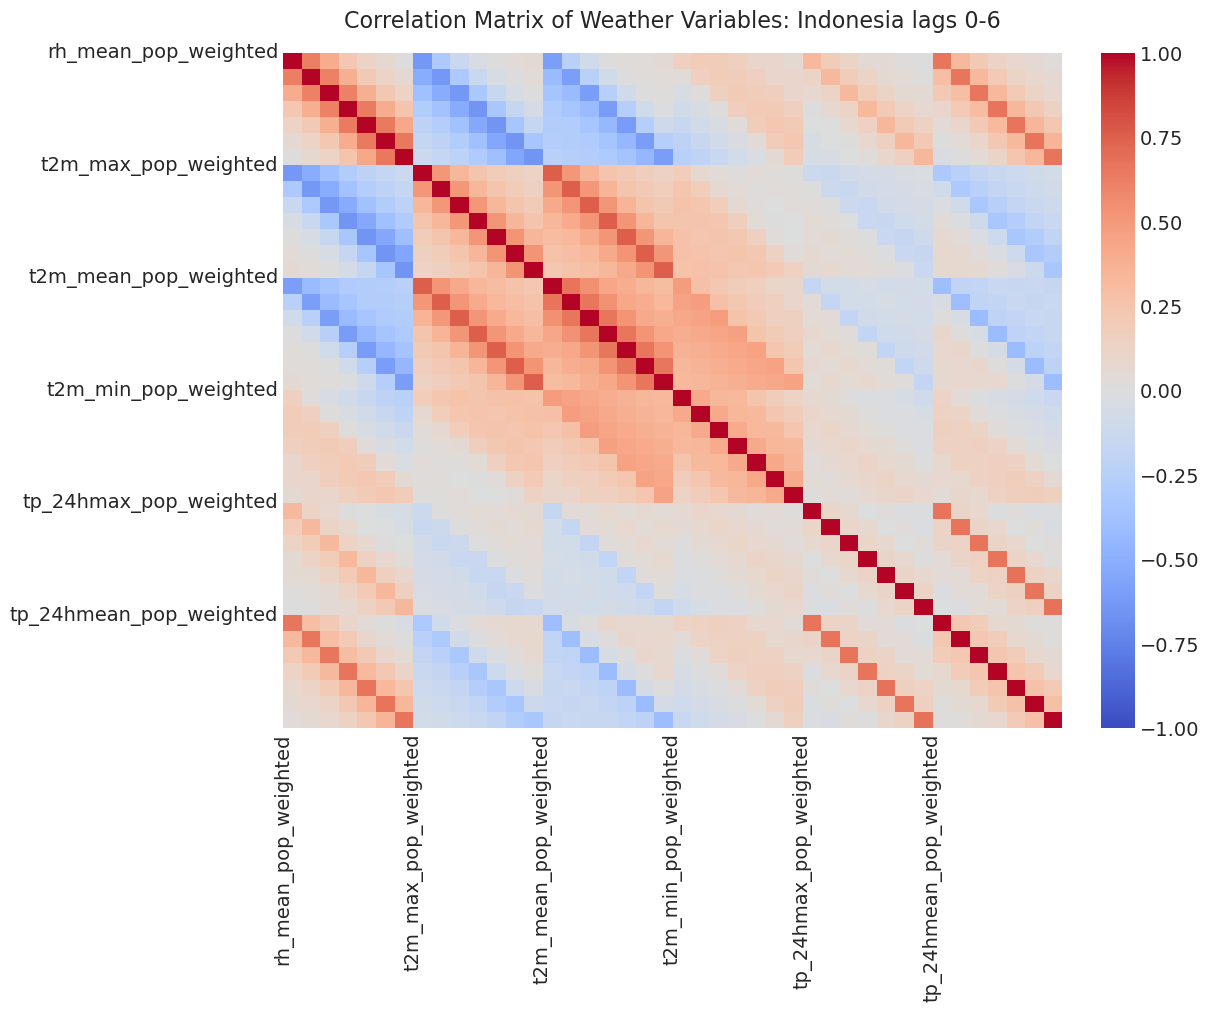

In [9]:
# use seaborn to plot the correlation matrix
plt.figure(figsize=(12, 10))
colormap = ['coolwarm', 'seismic'][0]
sns.heatmap(anom_data[anom_cov_columns].corr(), annot=False, cmap=colormap, vmin=-1, vmax=1)
plt.title('Correlation Matrix of Weather Variables: Indonesia lags 0-6', y=1.025)
# instead of using all column names, use only every sixth column name, and remove the lag number
xticks = [i for i in range(len(anom_cov_columns)) if i % 7 == 0]
xtick_labels = [anom_cov_columns[i].split('(')[0] for i in xticks]
plt.xticks(xticks, xtick_labels, rotation=90)
yticks = [i for i in range(len(w_cov_columns)) if i % 7 == 0]
ytick_labels = [w_cov_columns[i].split('(')[0] for i in yticks]
plt.yticks(yticks, ytick_labels, rotation=0)
# can you shift the ticks a bit to the right and downwards so they are not on the grid lines?
plt.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=True, labeltop=False, labelrotation=90)
plt.tick_params(axis='y', which='both', left=False, right=False, labelleft=True, labelright=False)
plt.show()

This has lower values than the previous matrix so annual cycle was accounting for some correlation. The values are now deviations from the region_month mean.

---

## Correlations by region

- Correlation matrices for each region, in batches

# batch and save covariance heatmaps into 4 separate folders (one per cmap/anom combination)
cols = 4
rows = 16
n_plots = cols * rows
batch_size = 64

out_dirs = {
    "non_anom_coolwarm": "cov_non_anom_coolwarm",
    "non_anom_seismic": "cov_non_anom_seismic",
    "anom_coolwarm": "cov_anom_coolwarm",
    "anom_seismic": "cov_anom_seismic",
}
for d in out_dirs.values():
    os.makedirs(d, exist_ok=True)

def make_figure(df, cols_list, cmap, regions_batch, out_fn):
    vmin, vmax = -1, 1
    fig_w = cols * 3
    fig_h = rows * 1.6
    fig, axes = plt.subplots(rows, cols, figsize=(fig_w, fig_h))
    axes = axes.flatten()
    for i in range(n_plots):
        ax = axes[i]
        if i < len(regions_batch):
            r = regions_batch[i]
            sub = df.loc[df['admin2'] == r, cols_list].dropna()
            if sub.shape[0] >= 2:
                cov = sub.corr()
                sns.heatmap(cov, ax=ax, cmap=cmap, vmin=vmin, vmax=vmax,
                            xticklabels=False, yticklabels=False, cbar=False)
            else:
                ax.text(0.5, 0.5, "insufficient\nrows", ha='center', va='center', fontsize=6)
                ax.set_xticks([]); ax.set_yticks([])
            ax.set_title(r, fontsize=6, pad=1)
        else:
            ax.axis('off')
    fig.savefig(out_fn, dpi=300, bbox_inches='tight')
    plt.close(fig)

n_batches = int(np.ceil(len(a2_regions) / batch_size))
for b in range(n_batches):
    batch_regions = a2_regions[b*batch_size:(b+1)*batch_size]
    idx = b + 1
    # non-anom coolwarm
    make_figure(data, weather_columns, cmap="coolwarm", regions_batch=batch_regions,
                out_fn=os.path.join(out_dirs["non_anom_coolwarm"], f"cov_non_anom_coolwarm_batch{idx:02d}.png"))
    # non-anom seismic
    make_figure(data, weather_columns, cmap="seismic", regions_batch=batch_regions,
                out_fn=os.path.join(out_dirs["non_anom_seismic"], f"cov_non_anom_seismic_batch{idx:02d}.png"))
    # anom coolwarm
    make_figure(data_anom, anom_cols, cmap="coolwarm", regions_batch=batch_regions,
                out_fn=os.path.join(out_dirs["anom_coolwarm"], f"cov_anom_coolwarm_batch{idx:02d}.png"))
    # anom seismic
    make_figure(data_anom, anom_cols, cmap="seismic", regions_batch=batch_regions,
                out_fn=os.path.join(out_dirs["anom_seismic"], f"cov_anom_seismic_batch{idx:02d}.png"))

- admin2 correlations by admin1

# Group covariance heatmaps by admin1: one figure per admin1 with subplots for each admin2 in that admin1
# Uses existing variables: data, data_anom, weather_columns, sns, plt, os, rows, cols

cols = 4
cmaps = {"coolwarm": "non_anom_coolwarm"} ##, "seismic": "non_anom_seismic"}
anom_cmaps = {} ##{"coolwarm": "anom_coolwarm", "seismic": "anom_seismic"}

out_base = "corr_by_admin1"
for d in [out_base]:
    os.makedirs(d, exist_ok=True)
for v in list(cmaps.values()) + list(anom_cmaps.values()):
    os.makedirs(os.path.join(out_base, v), exist_ok=True)

anom_cols = [c + "_anom" for c in weather_columns]

def safe_fn(s):
    return "".join(ch if ch.isalnum() or ch in "-_" else "_" for ch in s).strip("_").lower()

def make_admin1_figure(df, cols_list, cmap, admin1_name, out_fn):
    admin2_list = sorted(df.loc[df['admin1'] == admin1_name, 'admin2'].unique())
    n = len(admin2_list)
    if n == 0:
        return
    rows = max(1, int(np.ceil(n / cols)))
    fig_w = cols * 3
    fig_h = rows * 1.6
    fig, axes = plt.subplots(rows, cols, figsize=(fig_w, fig_h))
    axes = np.array(axes).reshape(-1)
    vmin, vmax = -1, 1
    for i, ax in enumerate(axes):
        if i < n:
            r = admin2_list[i]
            sub = df.loc[df['admin2'] == r, cols_list].dropna()
            if sub.shape[0] >= 2:
                cov = sub.corr()
                sns.heatmap(cov, ax=ax, cmap=cmap, vmin=vmin, vmax=vmax,
                            xticklabels=False, yticklabels=False, cbar=False)
            else:
                ax.text(0.5, 0.5, "insufficient\nrows", ha='center', va='center', fontsize=6)
                ax.set_xticks([]); ax.set_yticks([])
            ax.set_title(r, fontsize=6, pad=1)
        else:
            ax.axis('off')
    fig.suptitle(f"{admin1_name} — {os.path.basename(out_fn)}", fontsize=10)
    fig.savefig(out_fn, dpi=300, bbox_inches='tight')
    plt.close(fig)

admin1_list = sorted(data['admin1'].unique())

for admin1_name in admin1_list:
    fn_base = safe_fn(admin1_name)
    # non-anom maps
    for cmap, subdir in cmaps.items():
        out_fn = os.path.join(out_base, subdir, f"{fn_base}_non_anom_{cmap}.png")
        make_admin1_figure(data, weather_columns, cmap, admin1_name, out_fn)
    # anom maps
    for cmap, subdir in anom_cmaps.items():
        out_fn = os.path.join(out_base, subdir, f"{fn_base}_anom_{cmap}.png")
        make_admin1_figure(data_anom, anom_cols, cmap, admin1_name, out_fn)

- admin2 covariances (scaling each weather statistic) by admin1

In [10]:
# compute global vmin/vmax of covariances across admin2, then make covariance heatmap figures
# instead of min and max of covariance matrices, use 5 and 95 percentiles for vmin and vmax
    
def compute_cov_range_quantile(df, cols_list, regs, q_low=0.05, q_high=0.95):
    all_cov_values = np.array([])
    for r in regs:
        sub = df.loc[df['admin2'] == r, cols_list].dropna()
        if sub.shape[0] >= 2:
            cov = sub.cov().values
            # concatenate all finite covariance values into a 1D array
            cov_values = cov[np.isfinite(cov)].flatten()
            all_cov_values = np.concatenate((all_cov_values, cov_values))
    q_low_val = np.nanquantile(all_cov_values, q_low)
    q_high_val = np.nanquantile(all_cov_values, q_high)
    return q_low_val, q_high_val

def compute_cov_range_min_max(df, cols_list, regs):
    all_cov_values = np.array([])
    for r in regs:
        sub = df.loc[df['admin2'] == r, cols_list].dropna()
        if sub.shape[0] >= 2:
            cov = sub.cov().values
            # concatenate all finite covariance values into a 1D array
            cov_values = cov[np.isfinite(cov)].flatten()
            all_cov_values = np.concatenate((all_cov_values, cov_values))
    mn = np.nanmin(all_cov_values)
    mx = np.nanmax(all_cov_values)
    return mn, mx

In [11]:
vql_non, vqh_non = compute_cov_range_quantile(w_data, w_cov_columns, admin2_list, q_low=0.05, q_high=0.95)
vql_anom, vqh_anom = compute_cov_range_quantile(anom_data, anom_cov_columns, admin2_list, q_low=0.05, q_high=0.95)

vmin_non, vmax_non = compute_cov_range_min_max(w_data, w_cov_columns, admin2_list)
vmin_anom, vmax_anom = compute_cov_range_min_max(anom_data, anom_cov_columns, admin2_list)

vql_non, vqh_non, vmin_non, vmax_non

(-0.20837275398717867,
 0.36823017082424286,
 -3.104463315283401,
 4.240316217444683)

In [ ]:
def cluster_cov_figures(df, cols_list, cluster_df, out_base,
                        vmin, vmax,
                        suffix="",
                        admin2_col='admin2', cluster_col='hc_cluster_id',
                        cmap='coolwarm'):
    norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)
    cols_per_row = 4
    max_rows_per_fig = 10
    max_per_fig = cols_per_row * max_rows_per_fig

    os.makedirs(out_base, exist_ok=True)

    clusters = cluster_df[cluster_col].unique()

    for cluster_label in sorted(clusters):
        a2_in_cluster = sorted(cluster_df.loc[cluster_df[cluster_col] == cluster_label, admin2_col].unique())

        # keep only those present in df
        a2_in_cluster = [a for a in a2_in_cluster if a in df[admin2_col].values]

        n_total = len(a2_in_cluster)
        if n_total == 0:
            continue

        # split into chunks
        chunks = [a2_in_cluster[i:i + max_per_fig] for i in range(0, n_total, max_per_fig)]

        for part_idx, chunk in enumerate(chunks, start=1):
            n = len(chunk)
            n_rows = int(np.ceil(n / cols_per_row))
            fig_w = cols_per_row * 3
            fig_h = n_rows * 1.6
            fig, axes = plt.subplots(n_rows, cols_per_row,
                                     figsize=(fig_w, fig_h))
            axes = np.array(axes).reshape(-1)

            for i, ax in enumerate(axes):
                if i < n:
                    r = chunk[i]
                    sub = df.loc[df[admin2_col] == r, cols_list].dropna()

                    if sub.shape[0] >= 2:
                        cov = sub.cov()
                        sns.heatmap(
                            cov,
                            ax=ax,
                            cmap=cmap,
                            norm=norm,
                            xticklabels=False,
                            yticklabels=False,
                            cbar=False)
                    else:
                        ax.text(
                            0.5, 0.5,
                            "insufficient\nrows",
                            ha='center',
                            va='center',
                            fontsize=6)
                        ax.set_xticks([])
                        ax.set_yticks([])
                    ax.set_title(r, fontsize=6, pad=1)
                else:
                    ax.axis('off')

            safe_label = "".join(
                ch if ch.isalnum() or ch in "-_"
                else "_"
                for ch in str(cluster_label)
            ).strip("_").lower()

            part_suffix = f"_part{part_idx}" if len(chunks) > 1 else ""
            fn = os.path.join(out_base,
                f"{safe_label}{part_suffix}"
                f"{('_' + suffix) if suffix else ''}.png")

            fig.suptitle(f"{cluster_col}: {cluster_label} (part {part_idx}/{len(chunks)})", fontsize=10)
            fig.savefig(fn, dpi=300, bbox_inches='tight')
            plt.close(fig)

In [21]:
def cluster_cov_mean_figures(
    df, cols_list, mean_cols, cluster_df, out_base,
    vmin, vmax,
    suffix="",
    admin2_col='admin2',
    cluster_col='hc_cluster_id',
    cmap='coolwarm'
):
    """
    df: dataframe with admin2 column and weather columns
    cols_list: list of weather columns to compute covariance
    mean_cols: list of columns to plot means (e.g., lag0 variables)
    cluster_df: dataframe with at least [admin2_col, cluster_col] columns
    out_base: output directory
    vmin, vmax: bounds for covariance heatmaps
    suffix: optional filename suffix
    """

    norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)
    cols_per_row = 4
    max_rows_per_fig = 10
    max_per_fig = cols_per_row * max_rows_per_fig

    os.makedirs(out_base, exist_ok=True)

    clusters = cluster_df[cluster_col].unique()

    for cluster_label in sorted(clusters):

        a2_in_cluster = sorted(
            cluster_df.loc[
                cluster_df[cluster_col] == cluster_label,
                admin2_col
            ].unique()
        )

        # keep only those present in df
        a2_in_cluster = [a for a in a2_in_cluster if a in df[admin2_col].values]

        n_total = len(a2_in_cluster)
        if n_total == 0:
            continue

        # split into chunks
        chunks = [a2_in_cluster[i:i + max_per_fig] for i in range(0, n_total, max_per_fig)]

        for part_idx, chunk in enumerate(chunks, start=1):
            n = len(chunk)
            n_rows = int(np.ceil(n / cols_per_row))
            fig_w = cols_per_row * 3
            fig_h = n_rows * 1.6

            # -----------------------
            # Covariance heatmaps
            # -----------------------
            fig, axes = plt.subplots(n_rows, cols_per_row,
                                     figsize=(fig_w, fig_h))
            axes = np.array(axes).reshape(-1)

            for i, ax in enumerate(axes):
                if i < n:
                    r = chunk[i]
                    sub = df.loc[df[admin2_col] == r, cols_list].dropna()

                    if sub.shape[0] >= 2:
                        cov = sub.cov()
                        sns.heatmap(
                            cov,
                            ax=ax,
                            cmap=cmap,
                            norm=norm,
                            xticklabels=False,
                            yticklabels=False,
                            cbar=False)
                    else:
                        ax.text(
                            0.5, 0.5,
                            "insufficient\nrows",
                            ha='center',
                            va='center',
                            fontsize=6)
                        ax.set_xticks([])
                        ax.set_yticks([])
                    ax.set_title(r, fontsize=6, pad=1)
                else:
                    ax.axis('off')

            safe_label = "".join(
                ch if ch.isalnum() or ch in "-_"
                else "_"
                for ch in str(cluster_label)
            ).strip("_")

            part_suffix = f"_part{part_idx}" if len(chunks) > 1 else ""
            fn_cov = os.path.join(out_base,
                f"{safe_label}{part_suffix}_cov{('_' + suffix) if suffix else ''}.png")

            fig.suptitle(f"{cluster_col}: {cluster_label} (part {part_idx}/{len(chunks)})", fontsize=10)
            fig.savefig(fn_cov, dpi=300, bbox_inches='tight')
            plt.close(fig)

            # -----------------------
            # Line plot of mean lag-0 variables
            # -----------------------
            fig, ax = plt.subplots(figsize=(max(8, n * 0.5), 4))
            for col in mean_cols:
                means = [df.loc[df[admin2_col] == r, col].mean() if r in df[admin2_col].values else np.nan for r in chunk]
                ax.plot(range(n), means, marker='o', label=col, linewidth=1)

            ax.set_xticks(range(n))
            ax.set_xticklabels(chunk, rotation=90, fontsize=6)
            ax.set_ylabel("Mean value")
            ax.set_title(f"{cluster_col}: {cluster_label} (part {part_idx}/{len(chunks)})")
            ax.legend(fontsize=6, ncol=2, loc='upper left', bbox_to_anchor=(1,1))
            ax.grid(True, linestyle='--', alpha=0.5)

            fn_line = os.path.join(out_base,
                f"{safe_label}{part_suffix}_mean{('_' + suffix) if suffix else ''}.png")
            fig.savefig(fn_line, dpi=300, bbox_inches='tight')
            plt.close(fig)


In [61]:
hc_cluster_df = pd.read_csv('clusters/admin2_hc_clusters(38)(EMD_weather_matrix(rh_mean,t2m_mean,t2m_max,t2m_min,tp_24hmean,tp_24hmax)(log_tp=False)(6)).csv')
admin1_cluster_df = pd.read_csv('clusters/admin2_to_admin1.csv')
region_cluster_df = pd.read_csv('clusters/admin2_to_region.csv')

In [29]:
cluster_cov_mean_figures(w_data, w_cov_columns, [c for c in w_cov_columns if c.endswith('(0)')],
                    cluster_df=hc_cluster_df,
                    out_base="weather_corr_cov/cov_mean_by_hc(45)((rh_mean,t2m_mean,t2m_max,t2m_min,tp_24hmean,tp_24hmax)(log_tp=False)(6))_coolwarm_quantile",
                    vmin=vql_non,
                    vmax=vqh_non,
                    suffix="",
                    cmap="coolwarm")

cluster_cov_mean_figures(w_data, w_cov_columns, [c for c in w_cov_columns if c.endswith('(0)')],
                    cluster_df=admin1_cluster_df,
                    out_base="weather_corr_cov/cov_mean_by_admin1",
                    cluster_col='admin1',
                    vmin=vql_non,
                    vmax=vqh_non,
                    suffix="",
                    cmap="coolwarm")

In [43]:
def cluster_cov_mean_mad(df, cols_list, mean_cols, cluster_df,
                         admin2_col='admin2', cluster_col='hc_cluster_id'):
    """
    Compute MAD of covariances and mean vectors per cluster.

    Returns a dataframe with one row per cluster:
    - cluster_label
    - cov_mad: sum of absolute differences from cluster mean covariance
    - mean_mad: sum of absolute differences from cluster mean vector
    """
    clusters = sorted(cluster_df[cluster_col].unique())
    results = []

    for cluster_label in clusters:
        a2_in_cluster = sorted(
            cluster_df.loc[cluster_df[cluster_col] == cluster_label, admin2_col].unique()
        )
        # only keep those present in df
        a2_in_cluster = [a for a in a2_in_cluster if a in df[admin2_col].values]

        if len(a2_in_cluster) == 0:
            continue

        # -----------------------
        # Covariance matrices
        # -----------------------
        covs = []
        for a2 in a2_in_cluster:
            sub = df.loc[df[admin2_col] == a2, cols_list].dropna()
            if sub.shape[0] >= 2:
                covs.append(sub.cov().values)
        if len(covs) == 0:
            cov_mad = np.nan
        else:
            covs = np.array(covs)  # shape: (n_regions, n_vars, n_vars)
            cov_mean = covs.mean(axis=0)
            cov_mad = np.mean(np.abs(covs - cov_mean))  # sum absolute differences

        # -----------------------
        # Mean vectors
        # -----------------------
        means = []
        for a2 in a2_in_cluster:
            sub = df.loc[df[admin2_col] == a2, mean_cols].dropna()
            if sub.shape[0] >= 1:
                means.append(sub.mean().values)
        if len(means) == 0:
            mean_mad = np.nan
        else:
            means = np.array(means)  # shape: (n_regions, n_mean_cols)
            mean_mean = means.mean(axis=0)
            mean_mad = np.mean(np.abs(means - mean_mean))  # sum absolute differences

        results.append({
            cluster_col: cluster_label,
            'cov_mad': cov_mad,
            'mean_mad': mean_mad,
            'n_regions': len(a2_in_cluster)
        })

    return pd.DataFrame(results)

In [62]:
cov_mean_mad_null = cluster_cov_mean_mad(w_data, w_cov_columns, [c for c in w_cov_columns if c.endswith('(0)')],
                    cluster_df=pd.DataFrame({ 'admin2': admin2_list, 'hc_cluster_id': 0 }), cluster_col='hc_cluster_id')
cov_mean_mad_hc = cluster_cov_mean_mad(w_data, w_cov_columns, [c for c in w_cov_columns if c.endswith('(0)')],
                    cluster_df=hc_cluster_df, cluster_col='hc_cluster_id')
cov_mean_mad_admin1 = cluster_cov_mean_mad(w_data, w_cov_columns, [c for c in w_cov_columns if c.endswith('(0)')],
                    cluster_df=admin1_cluster_df, cluster_col='admin1')

In [63]:
cov_mad_null = np.sum(cov_mean_mad_null['cov_mad']*cov_mean_mad_null['n_regions'])
cov_mad_admin1 = np.sum(cov_mean_mad_admin1['cov_mad']*cov_mean_mad_admin1['n_regions'])
cov_mad_hc = np.sum(cov_mean_mad_hc['cov_mad']*cov_mean_mad_hc['n_regions'])

mean_mad_null = np.sum(cov_mean_mad_null['mean_mad']*cov_mean_mad_null['n_regions'])
mean_mad_admin1 = np.sum(cov_mean_mad_admin1['mean_mad']*cov_mean_mad_admin1['n_regions'])
mean_mad_hc = np.sum(cov_mean_mad_hc['mean_mad']*cov_mean_mad_hc['n_regions'])

In [64]:
print('admin1 cluster - hc difference in relative covariance MAD (relative to null cluster) \n',
      cov_mad_admin1/cov_mad_null - cov_mad_hc/cov_mad_null,
      '\n admin1 cluster - hc difference in relative mean MAD (relative to null cluster) \n',
      mean_mad_admin1/mean_mad_null - mean_mad_hc/mean_mad_null)

admin1 cluster - hc difference in relative covariance MAD (relative to null cluster) 
 -0.029438081434851493 
 admin1 cluster - hc difference in relative mean MAD (relative to null cluster) 
 0.29513603540869915


---

---
## incidence - weather response

In [ ]:
data = read_in(folder, admin=2, max_lag=6, dropna=True, start_year=2016, start_month=6, end_year=2024, end_month=12)


In [30]:
palette = 'blue'
if palette=='blue':
    color_95 = "#c3ceee"   # very light blue
    color_90 = "#95b8db"   # light blue
    color_75 = "#2777b0"   # medium blue
    median_color = '#08519c'
    mean_color = '#de2d26'
elif palette=='red':
    color_95 = '#fee5d9'   # very light red
    color_90 = '#fcbba1'   # light red
    color_75 = '#fb6a4a'   # medium red
    median_color = '#cb181d'
    mean_color = '#08519c'
elif palette=='purple':
    color_95 = '#f2f0f7'   # very light purple
    color_90 = '#e7e1ef'   # light purple
    color_75 = '#9e9ac8'   # medium purple
    median_color = '#6a51a3'
    mean_color = '#de2d26'
elif palette=='green':
    color_95 = '#edf8e9'   # very light green
    color_90 = '#c7e9c0'   # light green
    color_75 = '#74c476'   # medium green
    median_color = '#238b45'
    mean_color = '#de2d26'


In [ ]:
d_g0 = data.loc[data['rate'] > 0, :].copy()
d_g0 = data.copy()
# d_g0['rate'] = np.sqrt(np.sqrt(d_g0['rate']))

/tmp/ipykernel_2441170/1478824358.py:135: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


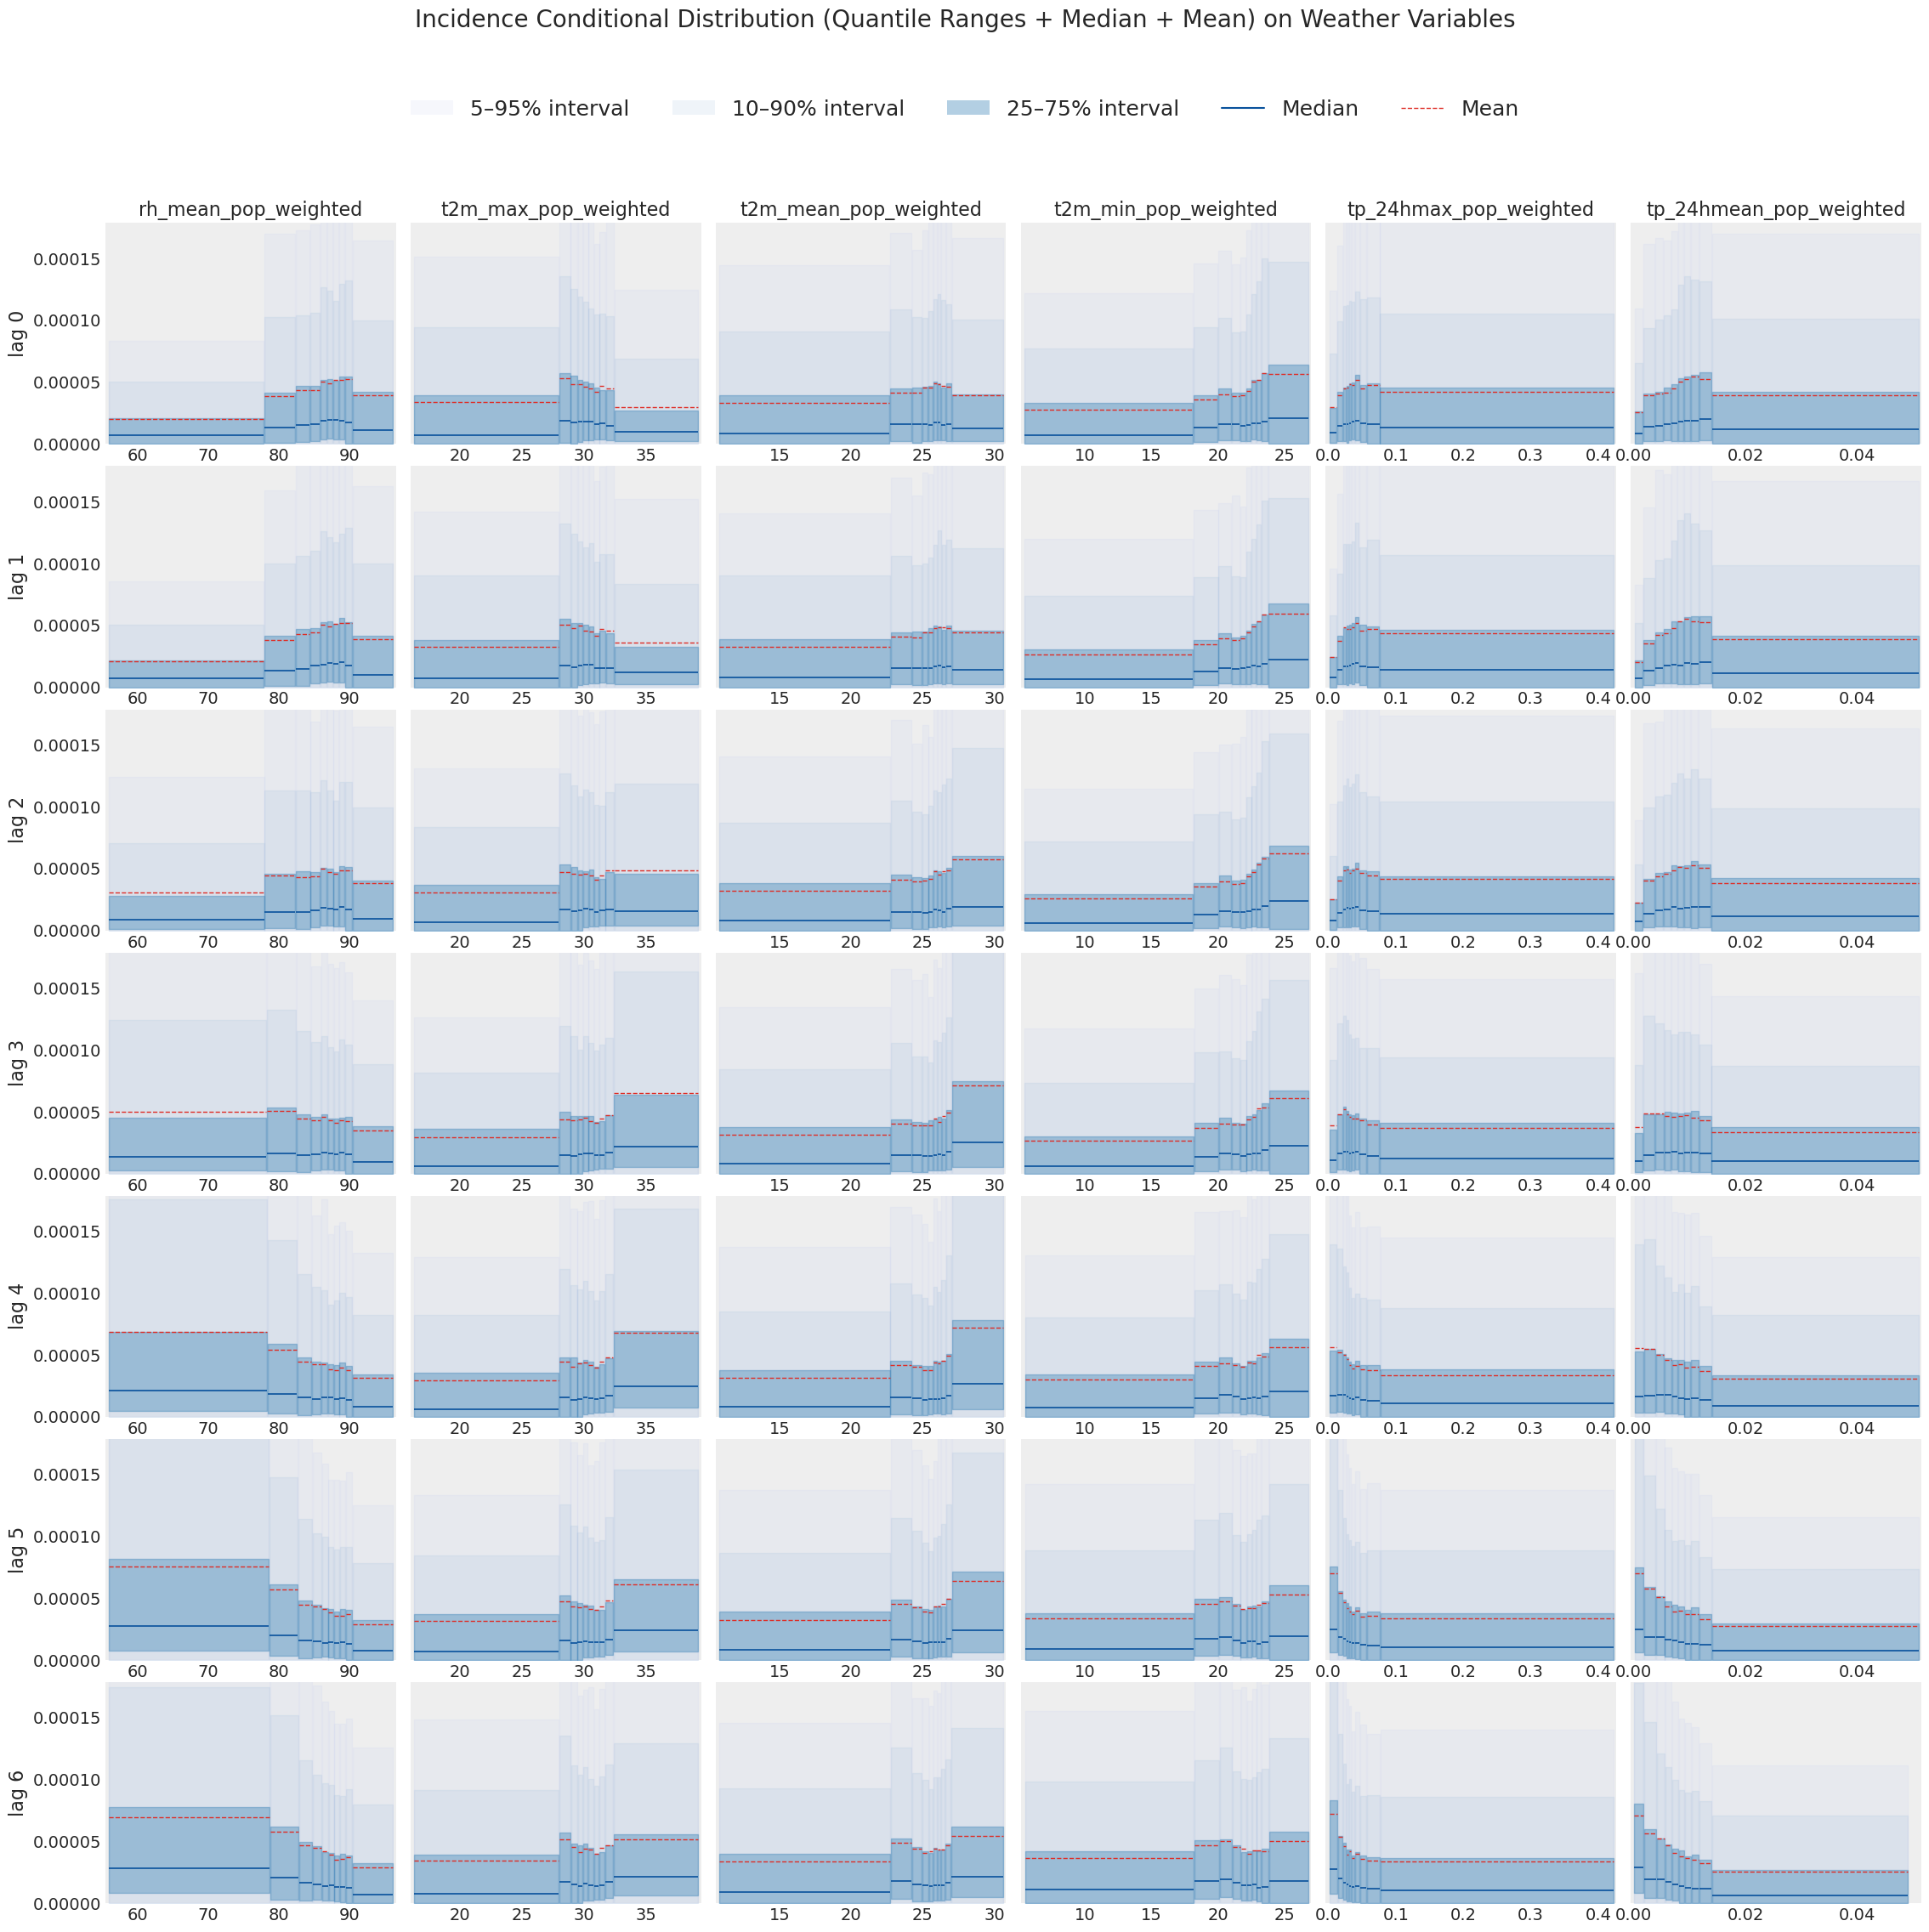

In [ ]:
k = 10  # number of equal-frequency x bins
chunk_size = 7
n_vars = len(weather_columns) // chunk_size

# Shared x-limits per variable
xlims = {}
for j in range(n_vars):
    cols = weather_columns[j*chunk_size:(j+1)*chunk_size]
    vals = d_g0[cols].stack().dropna().values
    lo, hi = vals.min(), vals.max()
    rng = hi - lo
    if rng == 0:
        lo -= 0.1; hi += 0.1
    else:
        lo -= 0.01 * rng; hi += 0.01 * rng
    xlims[j] = (lo, hi)

# Shared y-limits
ylims = np.percentile(d_g0['rate'], [5, 95])
ylims = [np.min(d_g0['rate']), ylims[1]]

fig, axes = plt.subplots(
    chunk_size, n_vars,
    figsize=(n_vars * 3.8, chunk_size * 3.0),
    sharey=True
)

for j in range(n_vars):
    base_name = weather_columns[j * chunk_size].split('(')[0]

    for i in range(chunk_size):
        col_name = weather_columns[j * chunk_size + i]
        ax = axes[i, j]
        sub = d_g0[[col_name, 'rate']].dropna()

        if sub.shape[0] >= k * 5:

            x = sub[col_name].values
            y = sub['rate'].values

            # equal-frequency bins
            quantile_edges = np.quantile(x, np.linspace(0, 1, k + 1))
            quantile_edges = np.unique(quantile_edges)
            actual_k = len(quantile_edges) - 1

            for b in range(actual_k):
                lo_b, hi_b = quantile_edges[b]+0.00285*(np.max(x)-np.min(x)), quantile_edges[b + 1]

                if b == actual_k - 1:
                    mask = (x >= lo_b) & (x <= hi_b)
                else:
                    mask = (x >= lo_b) & (x < hi_b)

                y_bin = y[mask]
                if len(y_bin) < 5:
                    continue

                # quantiles
                q5, q10, q25, q50, q75, q90, q95 = np.percentile(
                    y_bin, [5, 10, 25, 50, 75, 90, 95]
                )

                # draw ribbons
                ax.fill_betweenx(
                    [q5, q95],
                    lo_b, hi_b,
                    alpha=0.15,
                    color=color_95
                )

                ax.fill_betweenx(
                    [q10, q90],
                    lo_b, hi_b,
                    alpha=0.15,
                    color=color_90
                )
                ax.fill_betweenx(
                    [q25, q75],
                    lo_b, hi_b,
                    alpha=0.35,
                    color=color_75
                )

                # median line
                ax.hlines(
                    q50,
                    lo_b,
                    hi_b,
                    linewidth=1.2,
                    color=median_color
                )
                # mean line
                ax.hlines(
                    y_bin.mean(),
                    lo_b,
                    hi_b,
                    linewidth=1,
                    color=mean_color,
                    linestyle='--'
                )

        ax.set_xlim(xlims[j])
        ax.set_ylim(ylims)
        ax.grid(alpha=0.0)

        if i == 0:
            ax.set_title(base_name, fontsize=16)

        if j == 0:
            ax.set_ylabel(f"lag {i}", fontsize=16)

from matplotlib.patches import Patch
from matplotlib.lines import Line2D

legend_elements = [
    Patch(facecolor=color_95, alpha=0.15, label='5–95% interval'),
    Patch(facecolor=color_90, alpha=0.15, label='10–90% interval'),
    Patch(facecolor=color_75, alpha=0.35, label='25–75% interval'),
    Line2D([0], [0], color=median_color, lw=1.5, label='Median'),
    Line2D([0], [0], color=mean_color, lw=1, linestyle='--', label='Mean')
]

fig.legend(
    handles=legend_elements,
    loc='upper center',
    ncol=5,
    frameon=False,
    fontsize=18,
    bbox_to_anchor=(0.5, 1.04)
)
fig.suptitle("Incidence Conditional Distribution (Quantile Ranges + Median + Mean) on Weather Variables", fontsize=20, y=1.08)
plt.tight_layout()
plt.subplots_adjust(wspace=0.05, hspace=0.1)
plt.show()


Conditional curves change gradually with lag, leading to quite different shapes. This is done by dividing weather variable data into groups of the same size of data points, and plotting mean, median and quantiles on each range. Seems like relationship does change with lag.
- quantile interval sizes grow markedly for reltive humidity, possibly showing a weaker relationship.
- quantile interval sizes decrease for precipitation statistics, possibly showing a stronger relationship.

/tmp/ipykernel_2441170/3537758956.py:57: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


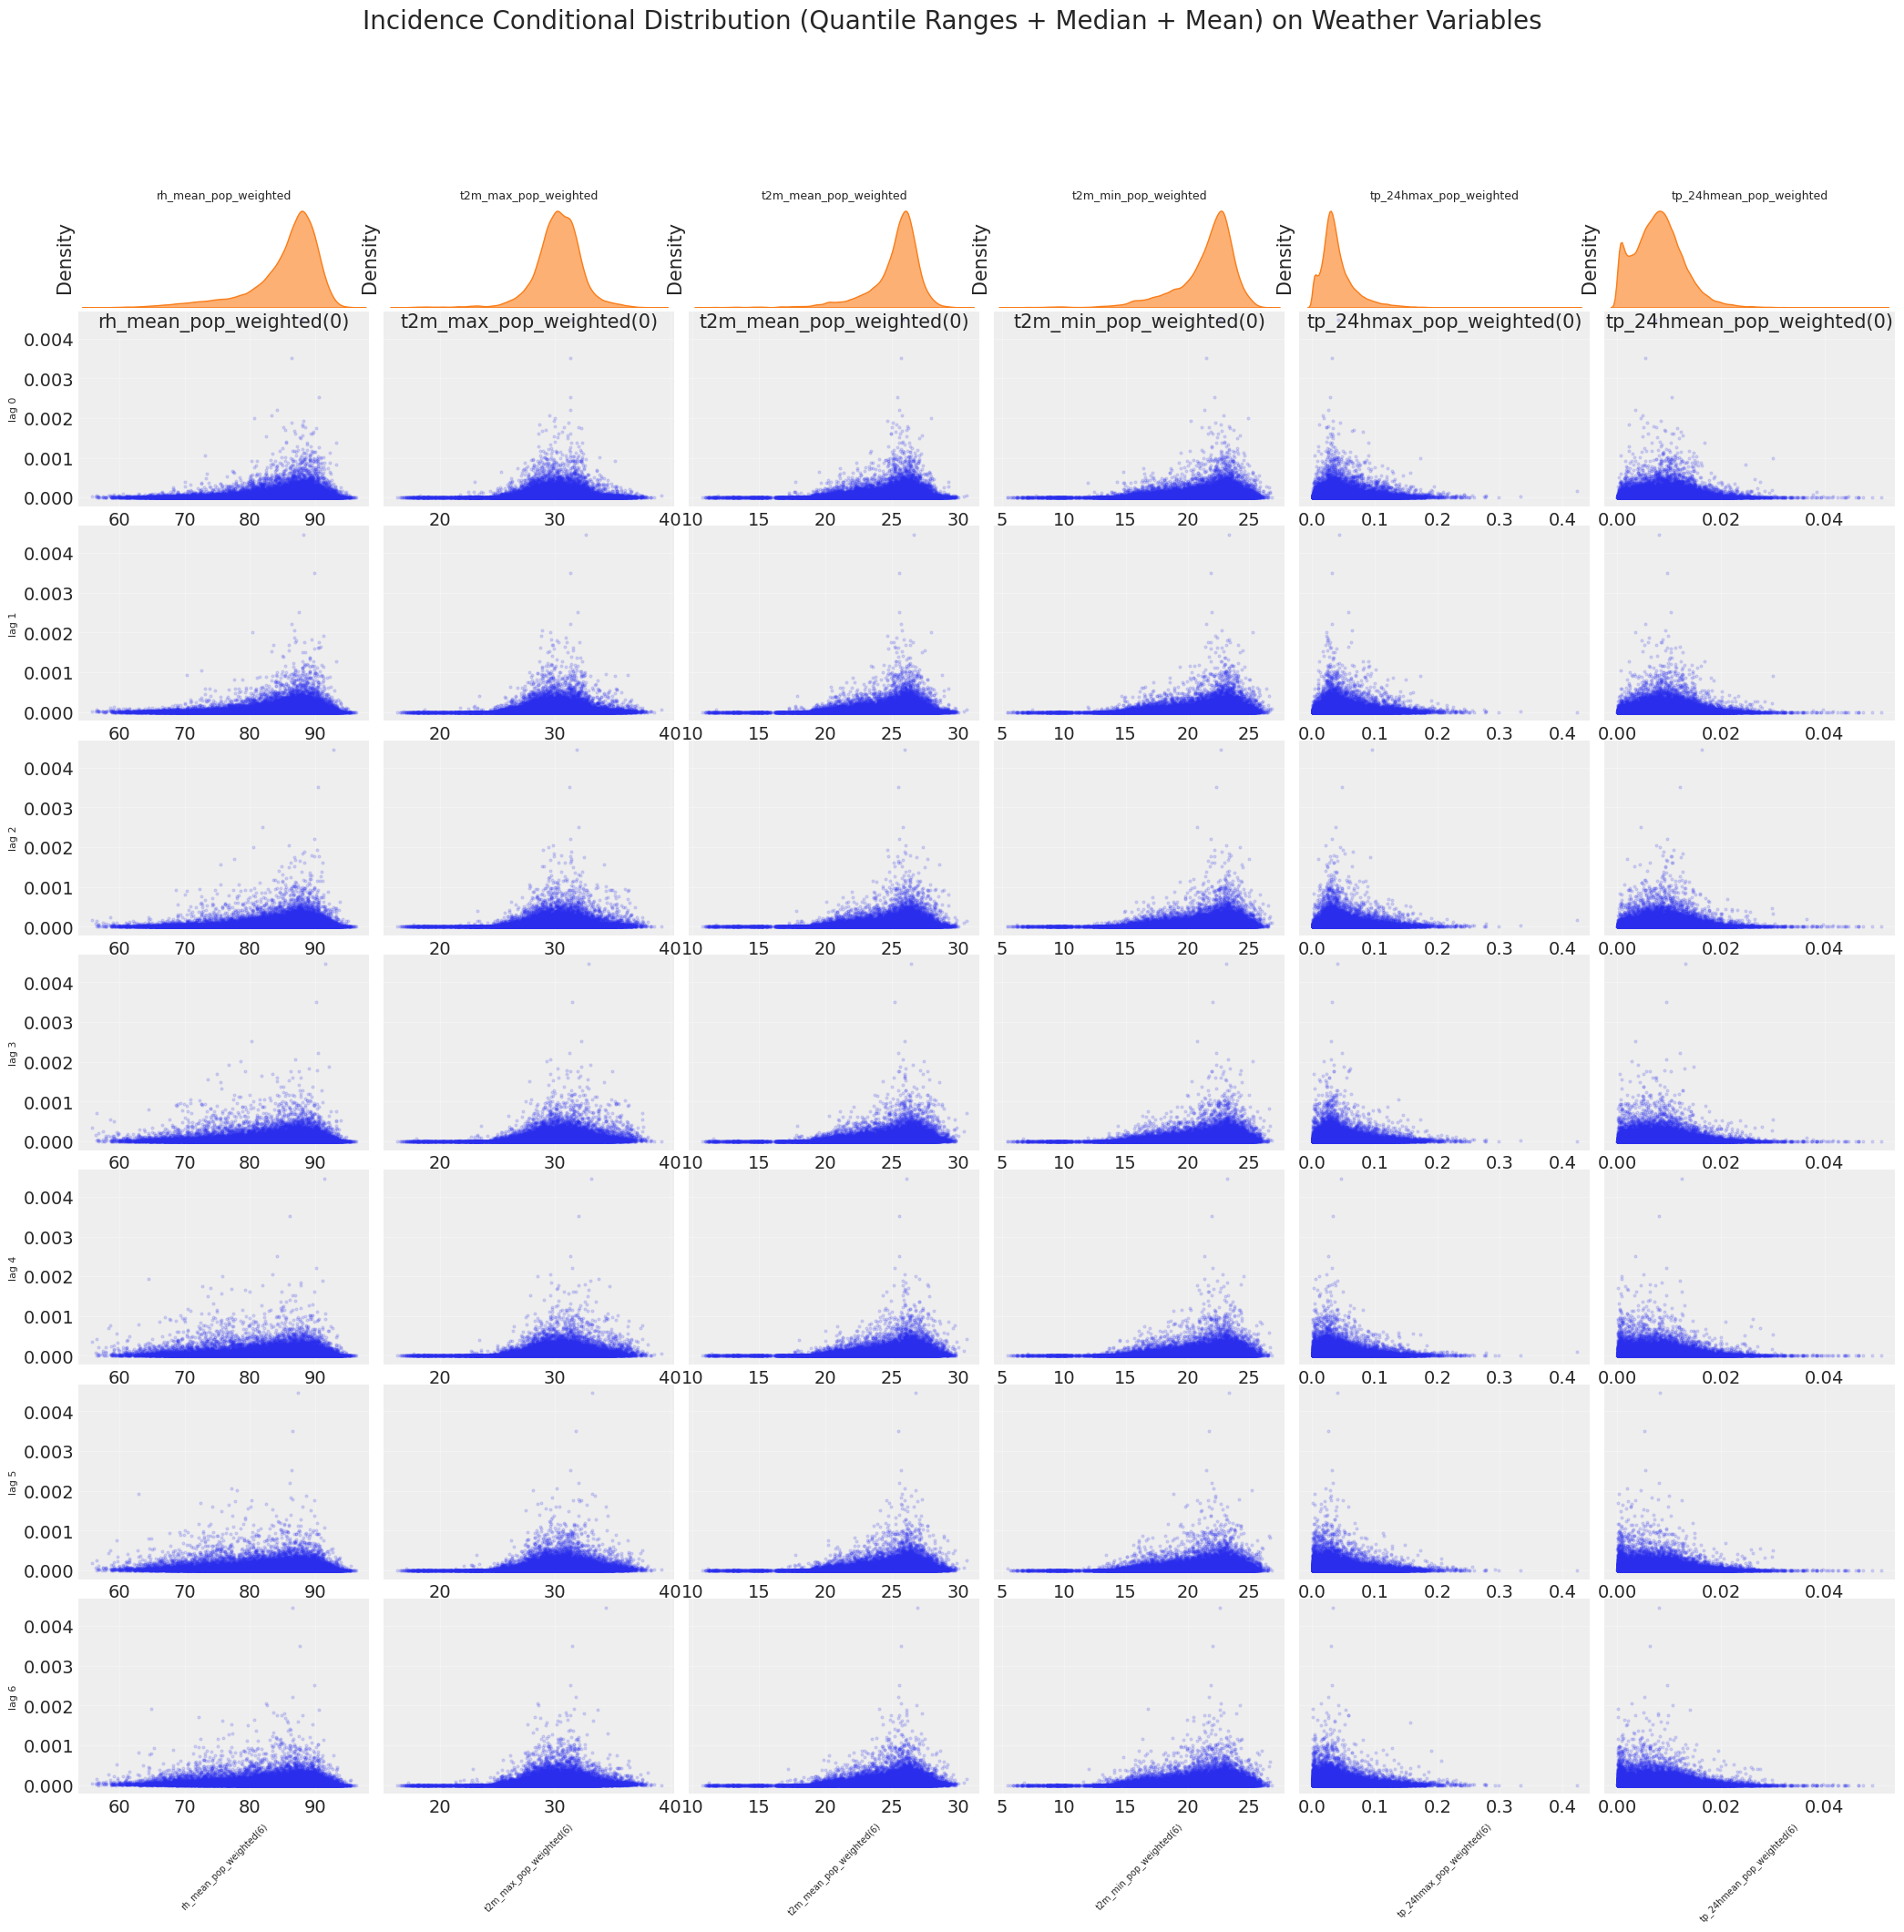

In [39]:
# compute shared x-limits per column (same limits for all lags of a variable)
chunk_size = 7
n_vars = len(weather_columns) // chunk_size

xlims = {}
for j in range(n_vars):
    cols = weather_columns[j*chunk_size:(j+1)*chunk_size]
    vals = d_g0[cols].stack().dropna().values
    lo, hi = vals.min(), vals.max()
    rng = hi - lo
    if rng == 0:
        lo -= 0.5
        hi += 0.5
    else:
        lo -= 0.05 * rng
        hi += 0.05 * rng
    xlims[j] = (lo, hi)

# plotting with fixed x-axis per column
fig, axes = plt.subplots(chunk_size, n_vars, figsize=(n_vars * 3.5, chunk_size * 2.8), sharey=True)
for j in range(n_vars):
    base_name = weather_columns[j * chunk_size].split('(')[0]
    for i in range(chunk_size):
        col_name = weather_columns[j * chunk_size + i]
        ax = axes[i, j]
        sub = d_g0[[col_name, 'rate']].dropna()
        if sub.shape[0] > 0:
            ax.scatter(sub[col_name], sub['rate'], s=4, alpha=0.15, rasterized=True)
            try:
                sns.regplot(x=col_name, y='rate', data=sub, ax=ax, scatter=False, lowess=True,
                            line_kws={'color': 'C1', 'linewidth': 1})
            except Exception:
                pass
            if sub.shape[0] >= 2 and i == 0:
                try:
                    ax_den = ax.inset_axes([0, 1.02, 1, 0.52], transform=ax.transAxes)
                    sns.kdeplot(sub[col_name], ax=ax_den, bw_adjust=0.8, fill=True, color='C1', alpha=0.6)
                    ax_den.set_xlim(ax.get_xlim())
                    ax_den.set_xticks([]); ax_den.set_yticks([])
                    ax_den.patch.set_alpha(0)
                except Exception:
                    try:
                        sns.kdeplot(sub[col_name], ax=ax, bw_adjust=0.8, color='C0', lw=1)
                        for lbl in ax.get_yticklabels():
                            lbl.set_visible(False)
                    except Exception:
                        pass
        ax.grid(alpha=0.3)
        ax.set_xlim(xlims[j])
        if i == 0:
            ax.set_title(base_name, fontsize=9)
        if j == 0:
            ax.set_ylabel(f"lag {i}", fontsize=8)
        if i == chunk_size - 1:
            ax.set_xlabel(col_name, fontsize=7, rotation=45)
fig.suptitle("Incidence Conditional Distribution (Quantile Ranges + Median + Mean) on Weather Variables", fontsize=20, y=1.08)
plt.tight_layout()
plt.subplots_adjust(wspace=0.05, hspace=0.1)
plt.show()

- pair plots on temperature do not seem to change much in lag
- pair plots on rh seem to change, flattening out to the left so that low values cause high incidence
- pair plots on tp seem to change, with some flattening and a column forming at zero (so zero tp at low lags matches with low incidence but zero tp at large lags has very spread out incidence values)
- changes are very small between adjacent lags.